In [ ]:
import os
import pickle
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import stats
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf



In [9]:
# downloading and saving S&P 500 data from 2005 to 2024
import requests
from io import StringIO

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}

response = requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', headers=headers)
table = pd.read_html(StringIO(response.text))
tickers = table[0]['Symbol'].tolist()
prices = yf.download(tickers, start='2005-01-01', end='2024-01-01')['Close']
prices.to_csv('data/sp500_prices.csv')

#downloading and saving VIX data from 2005 and 2024
vix = yf.download('^VIX', start='2005-01-01', end='2024-01-01')['Close']
vix.to_csv('data/vix.csv')

[************          25%                       ]  125 of 503 completed$GEV: possibly delisted; no price data found  (1d 2005-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1104555600, endDate = 1704085200")
[*************         28%                       ]  140 of 503 completed$SNDK: possibly delisted; no price data found  (1d 2005-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1104555600, endDate = 1704085200")
[**********************63%*****                  ]  318 of 503 completed$BF.B: possibly delisted; no price data found  (1d 2005-01-01 -> 2024-01-01)
[**********************63%*****                  ]  319 of 503 completed$SOLV: possibly delisted; no price data found  (1d 2005-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1104555600, endDate = 1704085200")
[**********************92%*******************    ]  465 of 503 completed$Q: possibly delisted; no price data found  (1d 2005-01-01 -> 2024-01-01) (

In [ ]:
# C 3: load from CSV and clean
prices = pd.read_csv('data/sp500_prices.csv', index_col=0, parse_dates=True)
vixData = pd.read_csv('data/vix.csv', index_col=0, parse_dates=True).squeeze()

# drop stocks with >20% missing
prices = prices.dropna(thresh=int(0.9 * len(prices)), axis=1)
prices = prices.ffill().bfill()

print(f"Stocks: {prices.shape[1]}  |  Days: {prices.shape[0]}")
print(f"Range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"VIX rows: {len(vixData)}")


Stocks: 414  |  Days: 4781
Range: 2005-01-03 to 2023-12-29
VIX rows: 4781


In [ ]:
# C 4: log returns
logReturns = np.log(prices/ prices.shift(1)).dropna()
print(f"Returns: {logReturns.shape}  (T x N)")


Returns: (4780, 414)  (T x N)


In [ ]:
# C 5: regime windows
regimes = {
    'Normal (2012-2014)': ('2012-01-01', '2014-12-31'),
    'GFC (2008-2009)':    ('2008-09-01', '2009-03-31'), #GFC = global financial crisis
    'COVID (2020)':       ('2020-02-01', '2020-05-31'),
}

regimeReturns = {}
for name, (start, end) in regimes.items():
    regimeReturns[name] = logReturns.loc[start:end]

for name, ret in regimeReturns.items():
    T, N = ret.shape
    print(f"{name:<25}  T={T:>4}  N={N:>4}  q={T/N:.3f}")


Normal (2012-2014)         T= 754  N= 414  q=1.821
GFC (2008-2009)            T= 146  N= 414  q=0.353
COVID (2020)               T=  82  N= 414  q=0.198


In [ ]:
# C 6: correlation matrix
def computeCorrelationMatrix(returns):
    if isinstance(returns, pd.DataFrame):
        returns = returns.values
    return np.corrcoef(returns.T)


In [ ]:
# C 7: eigendecomposition
def eigendecompose(C):
    vals, vecs = np.linalg.eigh(C)
    idx = np.argsort(vals)[::-1]
    return vals[idx], vecs[:, idx]


In [ ]:
# C 8: Marchenko-Pastur law
def computeLambdaPlus(q, sigma2):
    return sigma2 * (1 + 1 / np.sqrt(q)) ** 2

def computeLambdaMinus(q, sigma2):
    return sigma2 * (1 - 1 / np.sqrt(q)) ** 2

def mpDistribution(lambdaVals, q, sigma2):
    lp = computeLambdaPlus(q, sigma2)
    lm = computeLambdaMinus(q, sigma2)
    density = np.zeros_like(lambdaVals, dtype=float)
    mask = (lambdaVals >= lm) & (lambdaVals <= lp) & (lambdaVals > 0)
    l = lambdaVals[mask]
    density[mask] = (q / (2 * np.pi * sigma2)) * np.sqrt((lp - l) * (l - lm)) / l
    return density


In [ ]:
# C 9: fit MP — find best sigma^2
def fitMp(eigenvalues, q):
    bulk = eigenvalues[eigenvalues < 3.0 * eigenvalues.mean()]
    lambdaGrid = np.linspace(max(bulk.min() * 0.8, 1e-4), bulk.max() * 1.2, 500)

    def objective(params):
        s2 = float(params[0])
        if s2 <= 1e-6:
            return 1e10
        theory = mpDistribution(lambdaGrid, q, s2)
        theory = theory + 1e-12
        theory = theory / theory.sum()
        kde = stats.gaussian_kde(bulk)(lambdaGrid)
        kde = kde / kde.sum()
        mask = (theory > 1e-10) & (kde > 1e-10)
        return float(np.sum(kde[mask] * np.log(kde[mask] / theory[mask])))

    res = minimize(objective, x0=[1.0], method='Nelder-Mead',
                   options={'xatol': 1e-8, 'fatol': 1e-8, 'maxiter': 10000})
    sigma2 = float(res.x[0])
    lambdaPlus = computeLambdaPlus(q, sigma2)
    return sigma2, lambdaPlus


In [ ]:
# C 10: run RMT analysis on all three regimes
regimeAnalysis = {}

for name, ret in regimeReturns.items():
    T, N = ret.shape
    q = T / N
    C = computeCorrelationMatrix(ret)
    vals, vecs = eigendecompose(C)
    sigma2, lambdaPlus = fitMp(vals, q)
    nSignal = int((vals > lambdaPlus).sum())

    regimeAnalysis[name] = {
        'T': T, 'N': N, 'q': q,
        'C': C, 'eigenvalues': vals, 'eigenvectors': vecs,
        'sigma2': sigma2, 'lambdaPlus': lambdaPlus, 'nSignal': nSignal,
    }
    print(f"{name:<25}  q={q:.3f}  sigma2={sigma2:.4f}  "
          f"lambda+={lambdaPlus:.4f}  nSignal={nSignal}")


Normal (2012-2014)         q=1.821  sigma2=0.1063  lambda+=0.3223  nSignal=223
GFC (2008-2009)            q=0.353  sigma2=0.9498  lambda+=6.8416  nSignal=4
COVID (2020)               q=0.198  sigma2=0.1935  lambda+=2.0402  nSignal=16


In [ ]:
# C 11: denoise function + run on all regimes
def denoiseMatrix(eigenvalues, eigenvectors, lambdaPlus):
    lambdas = eigenvalues.copy()
    noiseMask = lambdas <= lambdaPlus
    if noiseMask.sum() > 0:
        lambdas[noiseMask] = lambdas[noiseMask].mean()

    cDenoised = eigenvectors @ np.diag(lambdas) @ eigenvectors.T

    # rescale diagonal back to 1
    d = np.sqrt(np.diag(cDenoised))
    d[d < 1e-10] = 1.0
    cDenoised = cDenoised / np.outer(d, d)
    np.fill_diagonal(cDenoised, 1.0)
    return cDenoised

for name, data in regimeAnalysis.items():
    cDn = denoiseMatrix(data['eigenvalues'], data['eigenvectors'], data['lambdaPlus'])
    regimeAnalysis[name]['cDenoised'] = cDn
    offDiagMean = (cDn.sum() - cDn.shape[0]) / (cDn.shape[0] * (cDn.shape[0] - 1))
    print(f"{name:<25}  off-diag mean corr = {offDiagMean:.4f}")


Normal (2012-2014)         off-diag mean corr = 0.3075
GFC (2008-2009)            off-diag mean corr = 0.5549
COVID (2020)               off-diag mean corr = 0.6235


In [ ]:
# C 12: rolling lambda_max vs VIX (60-day window)
# IMPORTANT: need T > N for a valid correlation matrix, so with a 60-day
# window we can use at most ~50 stocks (q = 60/50 = 1.2).
rollWindow = 60
rollStocks = logReturns.columns[:50]
cacheFile = 'data/rolling_analysis.pkl'

if os.path.exists(cacheFile):
    rollingDf = pd.read_pickle(cacheFile)
    print(f"Loaded from cache: {len(rollingDf)} windows")
else:
    retArr = logReturns[rollStocks].values
    dates = logReturns.index
    nRoll = retArr.shape[1]
    print(f"Rolling: T={rollWindow}, N={nRoll}, q={rollWindow/nRoll:.2f}")

    rollDates, rollLmax, rollNsignal = [], [], []

    for i in range(rollWindow, len(retArr)):
        window = retArr[i - rollWindow : i]

        # skip windows with any NaN (can happen at edges)
        if np.isnan(window).any():
            continue

        C = np.corrcoef(window.T)

        # safety: if corrcoef produced NaN, skip
        if np.isnan(C).any():
            continue

        vals = np.linalg.eigvalsh(C)[::-1]
        q = rollWindow / nRoll
        lp = computeLambdaPlus(q, sigma2=1.0)

        rollDates.append(dates[i])
        rollLmax.append(float(vals[0]))
        rollNsignal.append(int((vals > lp).sum()))

        if i % 1000 == 0:
            print(f"  {dates[i].date()}  lambdaMax={vals[0]:.3f}")

    rollingDf = pd.DataFrame(
        {'lambdaMax': rollLmax, 'nSignal': rollNsignal},
        index=rollDates,
    )
    rollingDf.to_pickle(cacheFile)
    print(f"Done — {len(rollingDf)} windows cached")

vixAligned = vixData.reindex(rollingDf.index, method='nearest')
rollingDf['vix'] = vixAligned.values
corrLmaxVix = rollingDf['lambdaMax'].corr(rollingDf['vix'])
print(f"Pearson(lambdaMax, VIX) = {corrLmaxVix:.3f}")


Loaded from cache: 3948 windows
Pearson(lambdaMax, VIX) = 0.622


In [ ]:
# C 13: portfolio construction — 4 methods
portfolioStocks = logReturns.columns[:100]
trainEnd = '2014-12-31'
testStart = '2015-01-01'

trainRet = logReturns.loc[:trainEnd, portfolioStocks]
testRet = logReturns.loc[testStart:, portfolioStocks]
tTrain, nPort = trainRet.shape
qPort = tTrain / nPort
stdVec = trainRet.std().values

def minVarianceWeights(covMatrix):
    N = covMatrix.shape[0]
    ones = np.ones(N)
    covReg = covMatrix + 1e-8 * np.eye(N)
    try:
        covInv = np.linalg.inv(covReg)
        w = covInv @ ones
        w = w / (ones @ w)
    except np.linalg.LinAlgError:
        w = ones / N
    w = np.maximum(w, 0)
    w = w / w.sum() if w.sum() > 0 else ones / N
    return w

# method 1: sample covariance
covSample = np.cov(trainRet.T) * 252
wSample = minVarianceWeights(covSample)

# method 2: Ledoit-Wolf shrinkage
lw = LedoitWolf().fit(trainRet.values)
covLw = lw.covariance_ * 252
wLw = minVarianceWeights(covLw)

# method 3: constant correlation
corrRaw = np.corrcoef(trainRet.T)
meanRho = (corrRaw.sum() - nPort) / (nPort * (nPort - 1))
cCc = np.full((nPort, nPort), meanRho)
np.fill_diagonal(cCc, 1.0)
covCc = np.outer(stdVec, stdVec) * cCc * 252
wCc = minVarianceWeights(covCc)

# method 4: RMT denoised
cTrain = computeCorrelationMatrix(trainRet)
evalsT, evecsT = eigendecompose(cTrain)
_, lpTrain = fitMp(evalsT, qPort)
cRmt = denoiseMatrix(evalsT, evecsT, lpTrain)
covRmt = np.outer(stdVec, stdVec) * cRmt * 252
wRmt = minVarianceWeights(covRmt)

allWeights = {
    'Sample': wSample,
    'Ledoit-Wolf': wLw,
    'Const Corr': wCc,
    'RMT Denoised': wRmt,
}

for mName, w in allWeights.items():
    effN = 1.0 / np.sum(w ** 2)
    print(f"{mName:<15}  maxW={w.max():.3f}  effN={effN:.1f}")


Sample           maxW=0.086  effN=26.0
Ledoit-Wolf      maxW=0.084  effN=26.6
Const Corr       maxW=0.063  effN=26.1
RMT Denoised     maxW=0.076  effN=26.3


In [ ]:
# C 14: out-of-sample validation
def portfolioMetrics(returnsSeries):
    annRet = returnsSeries.mean() * 252
    annVol = returnsSeries.std() * np.sqrt(252)
    sharpe = annRet / annVol if annVol > 1e-10 else 0.0
    cum = (1 + returnsSeries).cumprod()
    maxDd = (cum / cum.cummax() - 1).min()
    return {'annReturn': annRet, 'annVol': annVol, 'sharpe': sharpe, 'maxDd': maxDd}

testArr = testRet.values
perf = {}

for mName, w in allWeights.items():
    portRet = pd.Series(testArr @ w, index=testRet.index)
    m = portfolioMetrics(portRet)
    m['returns'] = portRet
    m['cumulative'] = (1 + portRet).cumprod()
    perf[mName] = m

print(f"{'Method':<15} {'Sharpe':>8} {'AnnVol':>8} {'AnnRet':>9} {'MaxDD':>8}")
print('-' * 54)
for mName, m in perf.items():
    print(f"{mName:<15}  {m['sharpe']:7.3f}  {m['annVol']:7.2%}  "
          f"{m['annReturn']:8.2%}  {m['maxDd']:7.2%}")


Method            Sharpe   AnnVol    AnnRet    MaxDD
------------------------------------------------------
Sample             0.741   15.79%    11.70%  -32.93%
Ledoit-Wolf        0.741   15.77%    11.69%  -32.85%
Const Corr         0.627   15.27%     9.58%  -30.01%
RMT Denoised       0.727   15.75%    11.45%  -32.49%


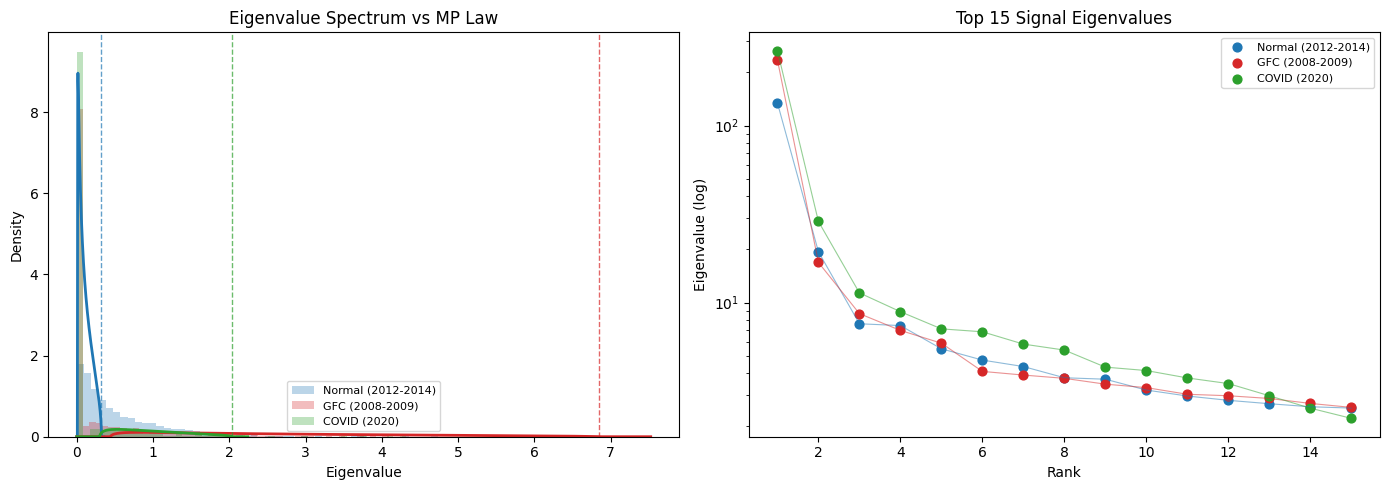

In [ ]:
# C 15: Plot 1 — Eigenvalue spectrum vs MP law
fig, (axBulk, axTail) = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Normal (2012-2014)': 'tab:blue', 'GFC (2008-2009)': 'tab:red', 'COVID (2020)': 'tab:green'}

for name, data in regimeAnalysis.items():
    vals = data['eigenvalues']
    q = data['q']
    s2 = data['sigma2']
    lp = data['lambdaPlus']

    # bulk histogram
    bulk = vals[vals <= 5]
    axBulk.hist(bulk, bins=50, density=True, alpha=0.3, color=colors[name], label=name)

    # MP curve
    grid = np.linspace(1e-4, lp * 1.1, 400)
    mp = mpDistribution(grid, q, s2)
    axBulk.plot(grid, mp, color=colors[name], lw=2)
    axBulk.axvline(lp, color=colors[name], ls='--', lw=1, alpha=0.7)

    # tail: top 15 eigenvalues
    top15 = np.sort(vals)[::-1][:15]
    axTail.scatter(range(1, 16), top15, color=colors[name], s=40, label=name)
    axTail.plot(range(1, 16), top15, color=colors[name], lw=0.8, alpha=0.5)

axBulk.set_xlabel('Eigenvalue')
axBulk.set_ylabel('Density')
axBulk.set_title('Eigenvalue Spectrum vs MP Law')
axBulk.legend(fontsize=8)

axTail.set_xlabel('Rank')
axTail.set_ylabel('Eigenvalue (log)')
axTail.set_yscale('log')
axTail.set_title('Top 15 Signal Eigenvalues')
axTail.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plots/plot1_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()


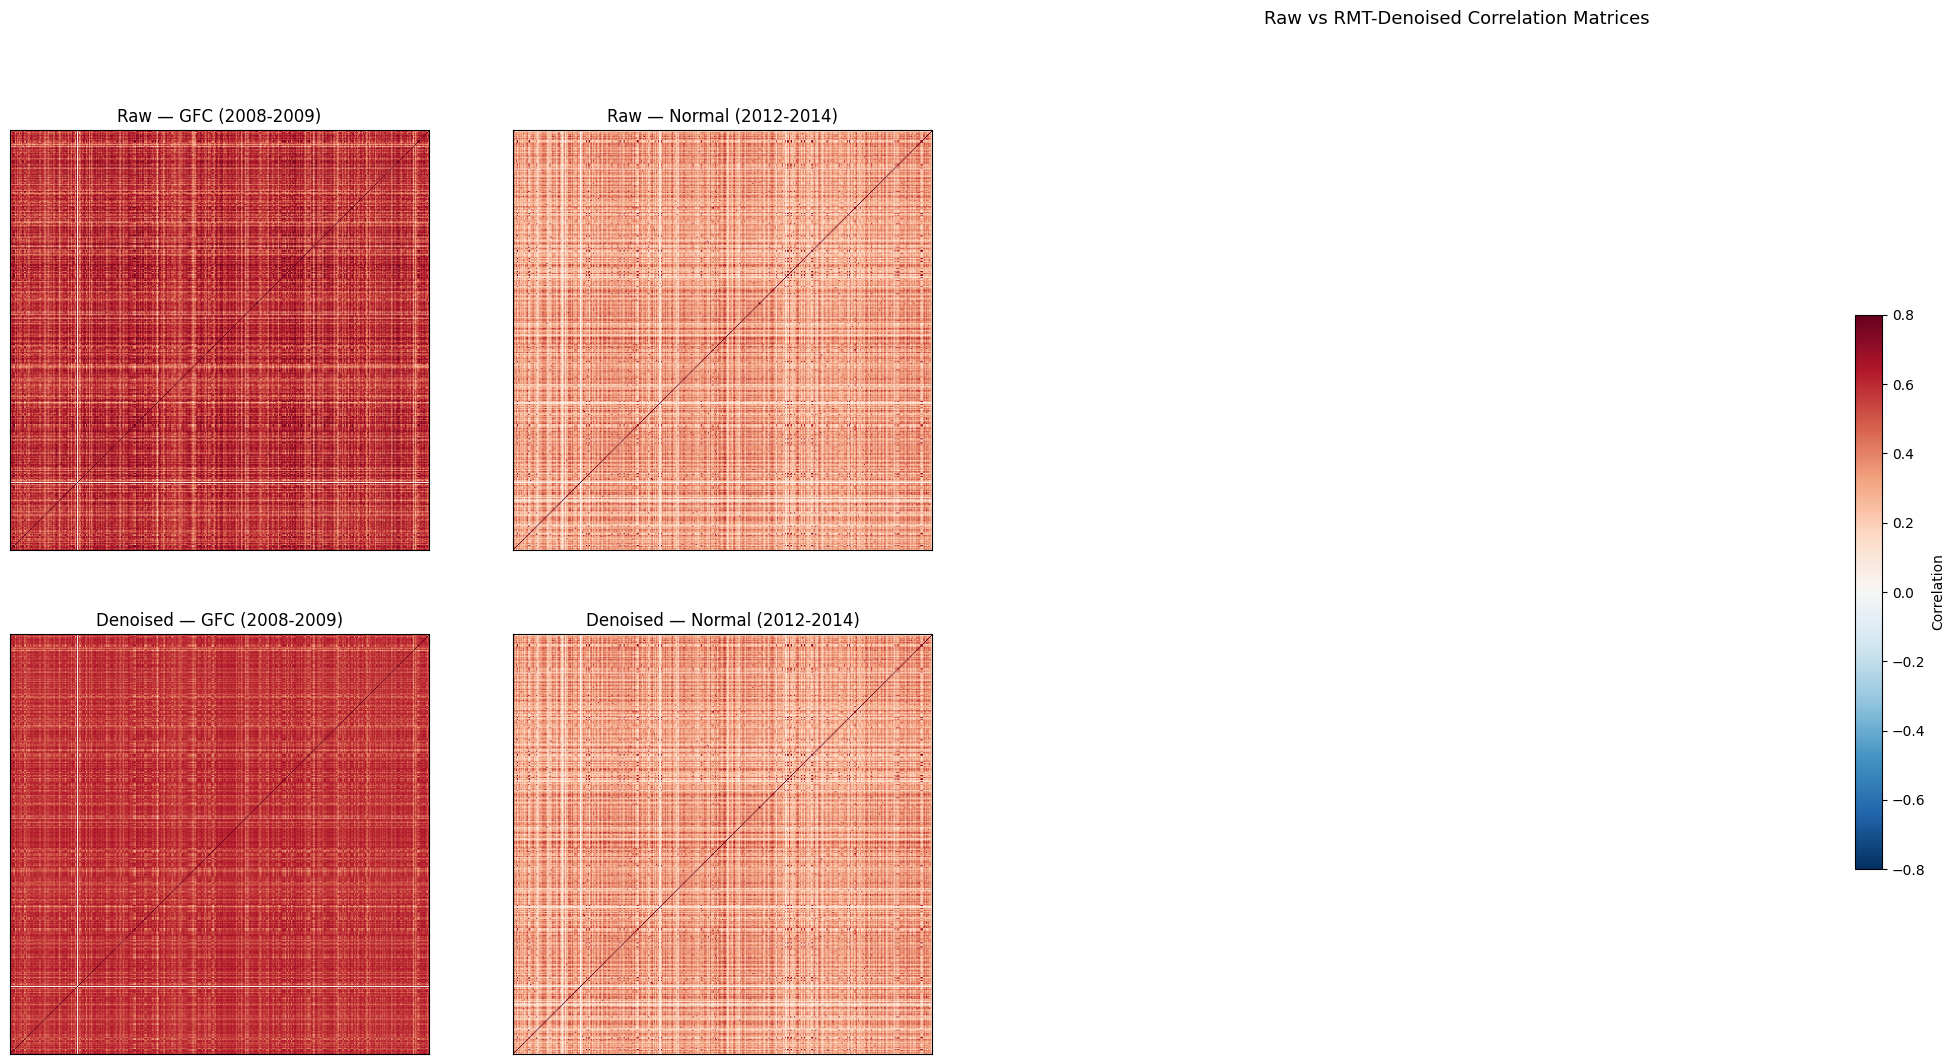

In [ ]:
# C 16: Plot 2 — Raw vs denoised correlation heatmaps
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

pairNames = ['Normal (2012-2014)', 'GFC (2008-2009)']

for col, rName in enumerate(pairNames):
    axes[0, col].imshow(regimeAnalysis[rName]['C'], cmap='RdBu_r', vmin=-0.8, vmax=0.8, aspect='auto')
    axes[0, col].set_title(f'Raw — {rName}')
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])

    im = axes[1, col].imshow(regimeAnalysis[rName]['cDenoised'], cmap='RdBu_r', vmin=-0.8, vmax=0.8, aspect='auto')
    axes[1, col].set_title(f'Denoised — {rName}')
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

plt.colorbar(im, ax=axes, shrink=0.6, label='Correlation',  pad = 1.7)
plt.suptitle('Raw vs RMT-Denoised Correlation Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('plots/plot2_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()


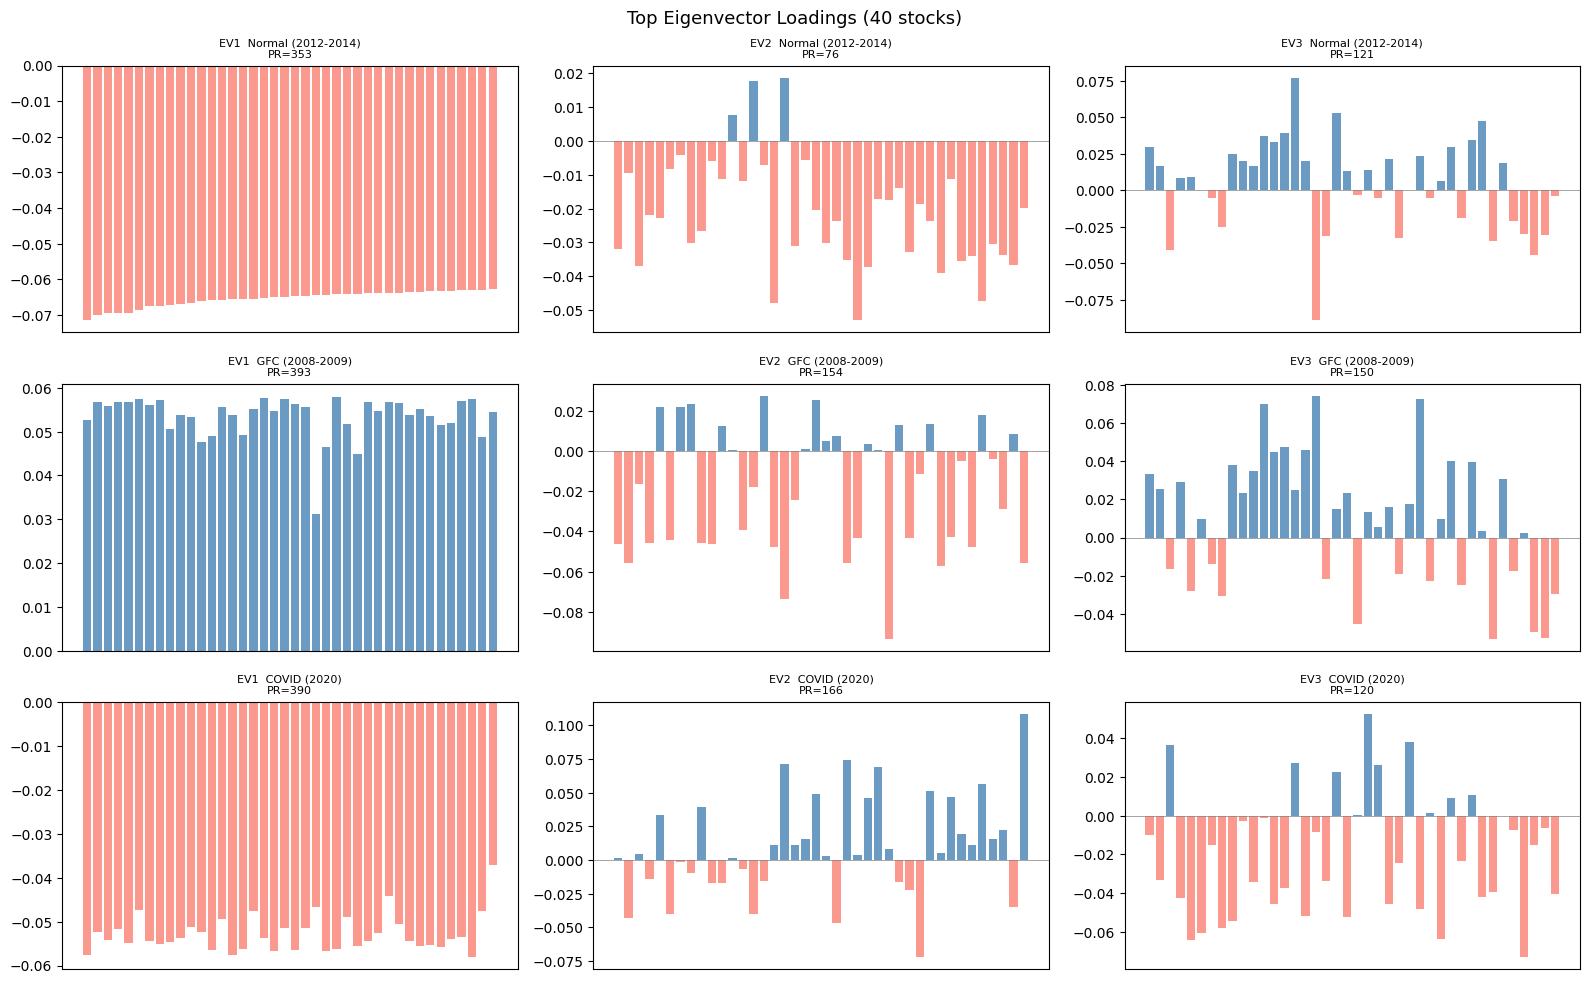

In [ ]:
# C 17: Plot 3 — Top eigenvector loadings
nEig = 3
nStocks = 40

refVals = regimeAnalysis['Normal (2012-2014)']['eigenvectors'][:, 0]
topIdx = np.argsort(np.abs(refVals))[::-1][:nStocks]

fig, axes = plt.subplots(len(regimeAnalysis), nEig, figsize=(16, 10))

for rowIdx, (rName, data) in enumerate(regimeAnalysis.items()):
    evecs = data['eigenvectors']
    for colIdx in range(nEig):
        ax = axes[rowIdx, colIdx]
        validIdx = topIdx[topIdx < evecs.shape[0]]
        loadings = evecs[validIdx, colIdx]
        barColors = ['steelblue' if v >= 0 else 'salmon' for v in loadings]
        ax.bar(range(len(loadings)), loadings, color=barColors, alpha=0.8)
        ax.axhline(0, color='gray', lw=0.5)
        pr = 1.0 / np.sum(evecs[:, colIdx] ** 4)
        ax.set_title(f"EV{colIdx+1}  {rName}\nPR={pr:.0f}", fontsize=8)
        ax.set_xticks([])

plt.suptitle('Top Eigenvector Loadings (40 stocks)', fontsize=13)
plt.tight_layout()
plt.savefig('plots/plot3_eigenvectors.png', dpi=150, bbox_inches='tight')
plt.show()


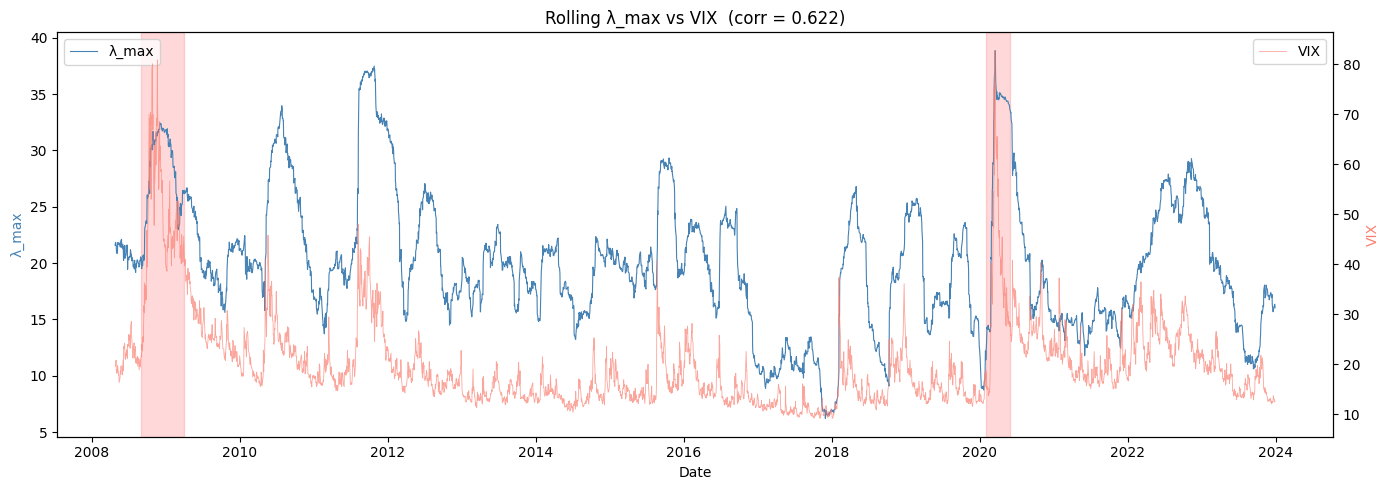

In [ ]:
# C 18: Plot 4 — Rolling lambda_max vs VIX
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(rollingDf.index, rollingDf['lambdaMax'], color='steelblue', lw=0.8, label='λ_max')
ax1.set_ylabel('λ_max', color='steelblue')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.plot(rollingDf.index, rollingDf['vix'], color='salmon', lw=0.6, alpha=0.7, label='VIX')
ax2.set_ylabel('VIX', color='salmon')

# crisis shading
for start, end, lbl in [('2008-09-01','2009-03-31','GFC'),
                          ('2020-02-01','2020-05-31','COVID')]:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color='red')

ax1.set_title(f'Rolling λ_max vs VIX  (corr = {corrLmaxVix:.3f})')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('plots/plot4_rolling_lambda.png', dpi=150, bbox_inches='tight')
plt.show()


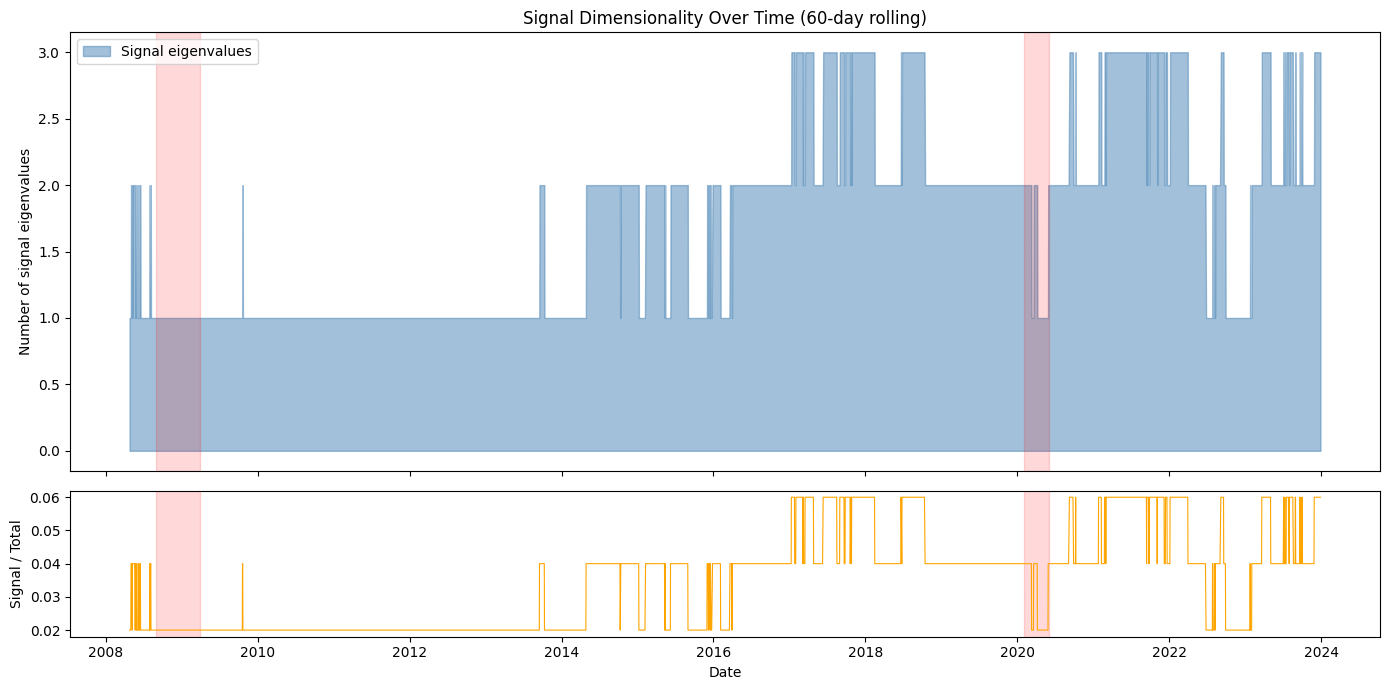

In [ ]:
# C 19: Plot 5 — Signal dimensionality over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.fill_between(rollingDf.index, rollingDf['nSignal'], alpha=0.5, color='steelblue', label='Signal eigenvalues')
ax1.set_ylabel('Number of signal eigenvalues')
ax1.set_title('Signal Dimensionality Over Time (60-day rolling)')
ax1.legend()

# ratio of signal to total
nTotal = len(rollStocks)
ax2.plot(rollingDf.index, rollingDf['nSignal'] / nTotal, color='orange', lw=0.8)
ax2.set_ylabel('Signal / Total')
ax2.set_xlabel('Date')

for start, end in [('2008-09-01','2009-03-31'), ('2020-02-01','2020-05-31')]:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color='red')
    ax2.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color='red')

plt.tight_layout()
plt.savefig('plots/plot5_signal_count.png', dpi=150, bbox_inches='tight')
plt.show()


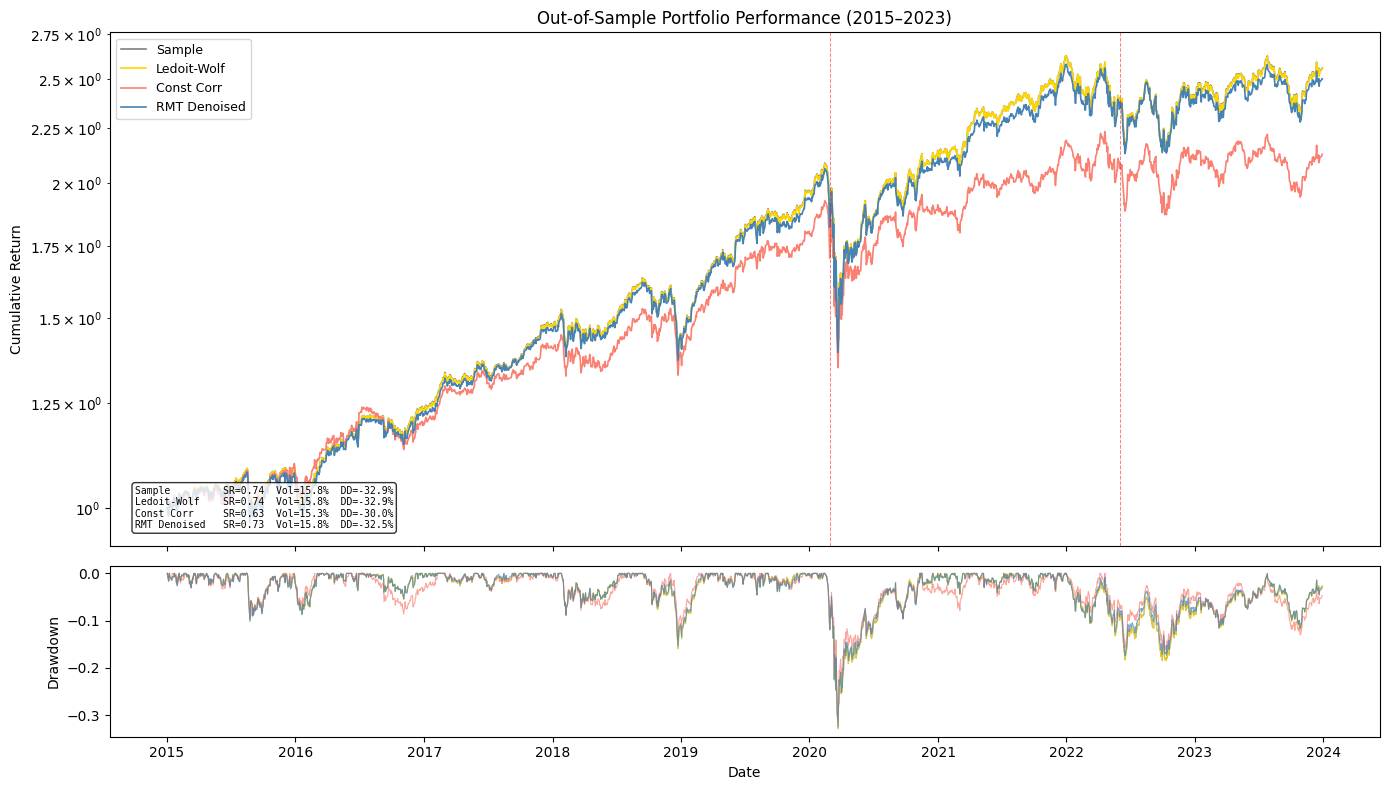

In [ ]:
# C 20: Plot 6 — Portfolio cumulative returns + drawdown
methodColors = {'Sample': 'gray', 'Ledoit-Wolf': 'gold', 'Const Corr': 'salmon', 'RMT Denoised': 'steelblue'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

for mName, m in perf.items():
    ax1.plot(m['cumulative'].index, m['cumulative'].values, label=mName, color=methodColors[mName], lw=1.2)
    dd = m['cumulative'] / m['cumulative'].cummax() - 1
    ax2.plot(dd.index, dd.values, color=methodColors[mName], lw=0.8, alpha=0.7)

ax1.set_ylabel('Cumulative Return')
ax1.set_title('Out-of-Sample Portfolio Performance (2015–2023)')
ax1.legend(fontsize=9)
ax1.set_yscale('log')

ax2.set_ylabel('Drawdown')
ax2.set_xlabel('Date')

# event lines
for date, lbl in [('2020-03-01', 'COVID'), ('2022-06-01', 'Rate hikes')]:
    ax1.axvline(pd.Timestamp(date), color='red', ls='--', lw=0.7, alpha=0.5)

# performance table
tableStr = '\n'.join([f"{m:<14} SR={perf[m]['sharpe']:.2f}  Vol={perf[m]['annVol']:.1%}  DD={perf[m]['maxDd']:.1%}"
                      for m in perf])
ax1.text(0.02, 0.03, tableStr, transform=ax1.transAxes, fontsize=7, family='monospace',
         va='bottom', bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
plt.savefig('plots/plot6_portfolios.png', dpi=150, bbox_inches='tight')
plt.show()


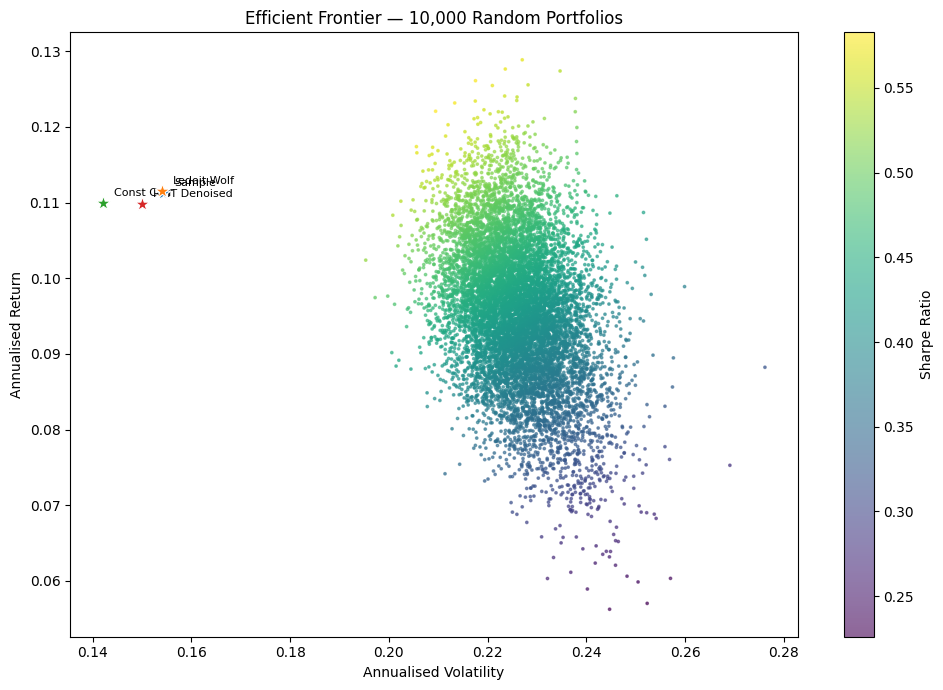

In [ ]:
# C 21: Plot 7 — Efficient frontier (hero plot)
np.random.seed(42)
nPortfolios = 10000
nAssets = covRmt.shape[0]

randReturns = []
randVols = []
randSharpes = []

meanReturns = trainRet.mean().values * 252

for _ in range(nPortfolios):
    w = np.random.dirichlet(np.ones(nAssets))
    pRet = w @ meanReturns
    pVol = np.sqrt(w @ covRmt @ w)
    sr = pRet / pVol if pVol > 1e-10 else 0
    randReturns.append(pRet)
    randVols.append(pVol)
    randSharpes.append(sr)

randReturns = np.array(randReturns)
randVols = np.array(randVols)
randSharpes = np.array(randSharpes)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(randVols, randReturns, c=randSharpes, cmap='viridis', s=3, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

# mark the 4 methods
for mName, w in allWeights.items():
    pRet = w @ meanReturns
    pVol = np.sqrt(w @ covRmt @ w)
    ax.scatter(pVol, pRet, s=120, marker='*', zorder=10, edgecolors='white', linewidths=0.8)
    ax.annotate(mName, (pVol, pRet), textcoords='offset points', xytext=(8, 5), fontsize=8)

ax.set_xlabel('Annualised Volatility')
ax.set_ylabel('Annualised Return')
ax.set_title('Efficient Frontier — 10,000 Random Portfolios')
plt.tight_layout()
plt.savefig('plots/plot7_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
